# 🎮 Steam Game Recommender

Content-based recommendation system built on Steam Games Dataset 2025.

**Approach 1:** TF-IDF + Cosine Similarity (Content-Based Filtering)  
**Approach 2:** ALS — Alternating Least Squares (Collaborative Filtering)  
**Author:** ete9nal

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import ast
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from implicit.als import AlternatingLeastSquares
import warnings

sys.path.append(os.path.abspath('..'))
from src.recommender import get_recommendations

warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


## 2. Data Loading

In [2]:
df = pd.read_csv('../data/games_march2025_full.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (94948, 47)


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366


## 3. EDA

Quick look at review scores, genres distribution, and missing values.

In [3]:
# Check missing values in key columns
cols = ['name', 'genres', 'tags', 'about_the_game', 'pct_pos_total', 'num_reviews_total']
print('Missing values:')
print(df[cols].isnull().sum())

Missing values:
name                    2
genres                  0
tags                    0
about_the_game       5449
pct_pos_total           0
num_reviews_total       0
dtype: int64


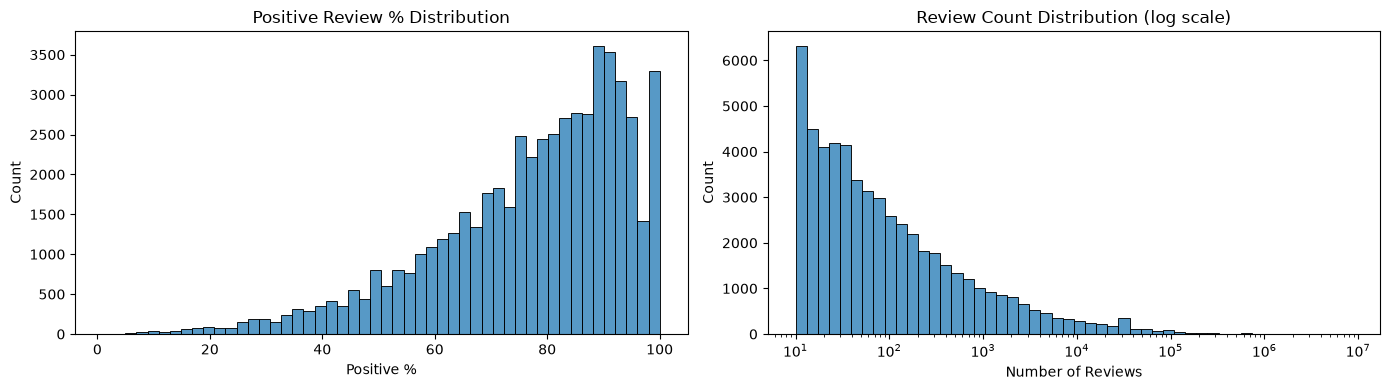

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Positive review % distribution (exclude -1 = no reviews)
sns.histplot(df[df['pct_pos_total'] > 0]['pct_pos_total'], bins=50, ax=axes[0])
axes[0].set_title('Positive Review % Distribution')
axes[0].set_xlabel('Positive %')

# Review count distribution (log scale)
sns.histplot(df[df['num_reviews_total'] > 0]['num_reviews_total'], log_scale=True, bins=50, ax=axes[1])
axes[1].set_title('Review Count Distribution (log scale)')
axes[1].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.show()

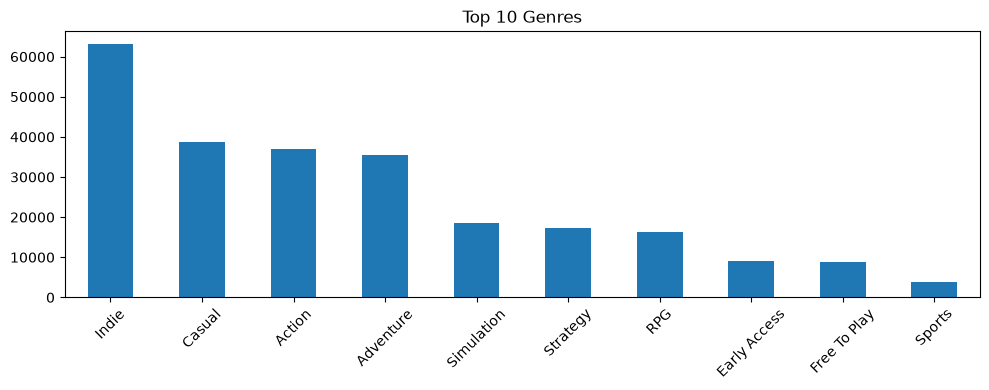

In [5]:
# Top 10 genres across all games
all_genres = []
for g in df['genres'].dropna():
    try:
        all_genres.extend(ast.literal_eval(g))
    except:
        pass

pd.Series(all_genres).value_counts().head(10).plot(kind='bar', figsize=(10, 4))
plt.title('Top 10 Genres')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Preprocessing

- Remove games with no description, genres, or tags
- Remove Playtest and Demo games (no real content)
- Parse genres/tags from string to plain text for TF-IDF

In [6]:
# Drop rows with missing required fields
df_filtered = df[
    df['about_the_game'].notna() &
    df['genres'].notna() &
    df['tags'].notna() &
    df['name'].notna()
].copy()

# Remove Playtest and Demo games
df_filtered = df_filtered[
    ~df_filtered['name'].str.contains('Playtest|Demo', case=False, na=False)
].reset_index(drop=True)

print(f'Original:        {df.shape[0]:,} games')
print(f'After filtering: {df_filtered.shape[0]:,} games')

Original:        94,948 games
After filtering: 89,156 games


In [7]:
# Parse list/dict stored as string -> plain text for TF-IDF
def parse_to_text(val):
    if not isinstance(val, str) or val.strip() == '':
        return ''
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, dict):  # tags: {'Tag': count, ...} -> 'Tag1 Tag2 ...'
            return ' '.join(parsed.keys())
        if isinstance(parsed, list):  # genres: ['Action', ...] -> 'Action ...'
            return ' '.join(str(x) for x in parsed)
    except:
        pass
    return val

df_filtered['genres_text']     = df_filtered['genres'].apply(parse_to_text)
df_filtered['tags_text']       = df_filtered['tags'].apply(parse_to_text)
df_filtered['categories_text'] = df_filtered['categories'].apply(parse_to_text)

# Genres and tags repeated twice to give them higher weight vs description
df_filtered['combined_text'] = (
    df_filtered['genres_text']     + ' ' +
    df_filtered['genres_text']     + ' ' +
    df_filtered['tags_text']       + ' ' +
    df_filtered['tags_text']       + ' ' +
    df_filtered['categories_text'] + ' ' +
    df_filtered['about_the_game'].fillna('')
)

print('Sample combined_text:')
print(df_filtered['combined_text'].iloc[0][:300])

Sample combined_text:
Action Free To Play Action Free To Play FPS Shooter Multiplayer Competitive Action Team-Based e-sports Tactical First-Person PvP Online Co-Op Co-op Strategy Military War Difficult Trading Realistic Fast-Paced Moddable FPS Shooter Multiplayer Competitive Action Team-Based e-sports Tactical First-Pers


## 5. Content-Based Filtering (TF-IDF + Cosine Similarity)

We vectorize each game's `combined_text` with TF-IDF, then find the most similar games.
Full similarity matrix would need ~60 GB RAM, so we compute it in batches of 1000.

In [8]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95
)

X = vectorizer.fit_transform(df_filtered['combined_text'])
print(f'TF-IDF matrix shape: {X.shape}')

TF-IDF matrix shape: (89156, 10000)


In [9]:
# Compute top-50 similar games per game using batches to avoid MemoryError
top_k = 50
batch_size = 1000
n = X.shape[0]
top_indices = np.zeros((n, top_k), dtype=np.int32)

for start in range(0, n, batch_size):
    end = min(start + batch_size, n)
    batch_sim = cosine_similarity(X[start:end], X)                   # shape: (batch, n)
    batch_top = np.argsort(batch_sim, axis=1)[:, ::-1][:, :top_k]   # top-k descending
    top_indices[start:end] = batch_top
    if start % 10000 == 0:
        print(f'  {start}/{n} done...')

print(f'top_indices shape: {top_indices.shape}')

  0/89156 done...
  10000/89156 done...
  20000/89156 done...
  30000/89156 done...
  40000/89156 done...
  50000/89156 done...
  60000/89156 done...
  70000/89156 done...
  80000/89156 done...
top_indices shape: (89156, 50)


In [10]:
# Save artifacts for Streamlit app
np.save('../data/top_indices.npy', top_indices)

df_filtered[[
    'name', 'genres', 'tags', 'categories',
    'positive', 'negative', 'header_image', 'price',
    'pct_pos_total', 'num_reviews_total'
]].reset_index(drop=True).to_parquet('../data/games_cleaned.parquet', index=False)

df = pd.read_parquet('../data/games_cleaned.parquet')
print(f'Saved {len(df):,} games to parquet')

Saved 89,156 games to parquet


In [11]:
# Sanity check - do recommendations make sense?
for game in ['Counter-Strike 2', 'Dota 2', 'Grand Theft Auto V Legacy']:
    recs = get_recommendations(game, df, top_indices, top_n=5)
    print(f'\n{game}:')
    for i, r in enumerate(recs, 1):
        print(f'  {i}. {r}')


Counter-Strike 2:
  1. Counter-Strike: Source
  2. Counter-Strike Nexon
  3. Galactic Incoming
  4. FPSBois
  5. TOXIKK™

Dota 2:
  1. Rise of Legions
  2. Heroes of SoulCraft - Arcade MOBA
  3. Awesomenauts - the 2D moba
  4. Legendary Heroes
  5. Dungeon Defenders II

Grand Theft Auto V Legacy:
  1. Grand Theft Auto III – The Definitive Edition
  2. Grand Theft Auto V Enhanced
  3. Grand Theft Auto: Vice City – The Definitive Edition
  4. Grand Theft Auto IV: The Complete Edition
  5. Grand Theft Auto: San Andreas – The Definitive Edition


## 6. Evaluation — Content-Based

No explicit user data, so we define **ground truth** as games that:
- Share genre or tag with the query game
- Have `pct_pos_total >= 75%` and `num_reviews_total >= 50`

**Metrics:**
- **Precision@K** — fraction of top-K recs that are relevant
- **Recall@K** — fraction of all relevant games caught in top-K
- **NDCG@K** — like Precision but rewards relevant items ranked higher
- **Coverage@K** — fraction of catalog the model ever recommends

In [12]:
def evaluate_recommendations(game_title, df, top_indices_matrix, top_n=5):
    match = df[df['name'].str.contains(game_title, case=False, na=False)]
    if match.empty:
        return None, None, None
    match = match.iloc[0]

    # Parse genres and tags of the query game
    try:
        genres = set(ast.literal_eval(match['genres']))
    except:
        genres = set()

    try:
        parsed_tags = ast.literal_eval(match['tags'])
        tags = set(parsed_tags.keys()) if isinstance(parsed_tags, dict) else set(parsed_tags)
    except:
        tags = set()

    # Ground truth: games with genre/tag overlap + good reviews
    def genre_overlap(val):
        try: return bool(set(ast.literal_eval(val)) & genres)
        except: return False

    def tag_overlap(val):
        try:
            p = ast.literal_eval(val)
            return bool((set(p.keys()) if isinstance(p, dict) else set(p)) & tags)
        except: return False

    ground_truth = set(df[
        (df['pct_pos_total'] >= 75) &
        (df['num_reviews_total'] >= 50) &
        (df['genres'].apply(genre_overlap) | df['tags'].apply(tag_overlap))
    ]['name'])

    if not ground_truth:
        return 0, 0, 0

    recs = list(get_recommendations(game_title, df, top_indices_matrix, top_n=top_n))
    hits = len(set(recs) & ground_truth)

    precision = hits / top_n
    recall    = hits / len(ground_truth)
    dcg  = sum(1 / np.log2(i + 2) for i, g in enumerate(recs) if g in ground_truth)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(ground_truth), top_n)))
    ndcg = dcg / idcg if idcg > 0 else 0

    return precision, recall, ndcg


def calculate_coverage(top_indices_matrix, total_items, top_n=5):
    unique = set(top_indices_matrix[:, :top_n].flatten())
    return len(unique) / total_items

In [13]:
for game in ['Counter-Strike 2', 'Dota 2', 'Grand Theft Auto V Legacy']:
    p, r, n = evaluate_recommendations(game, df, top_indices, top_n=5)
    if p is not None:
        print(f'{game}:')
        print(f'  Precision@5: {p:.2f}  |  Recall@5: {r:.4f}  |  NDCG@5: {n:.2f}')

coverage = calculate_coverage(top_indices, len(df), top_n=5)
print(f'\nCoverage@5: {coverage:.2%}')

Counter-Strike 2:
  Precision@5: 0.40  |  Recall@5: 0.0001  |  NDCG@5: 0.47
Dota 2:
  Precision@5: 0.60  |  Recall@5: 0.0002  |  NDCG@5: 0.64
Grand Theft Auto V Legacy:
  Precision@5: 0.60  |  Recall@5: 0.0002  |  NDCG@5: 0.45

Coverage@5: 99.93%


## 7. Collaborative Filtering — ALS (Alternating Least Squares)

ALS learns latent factors for users and items from interaction data.
We don't have real users, so we use **genres as users** and **games as items**.

If a game belongs to a genre → positive interaction (implicit feedback).
The more genres a game has, the more interactions it generates.

This answers: *'what games are most similar to this genre profile?'*  
It also handles **cold start** via genre/tag features.


In [14]:
# Build genre -> game interaction matrix
df_als = pd.read_parquet('../data/games_cleaned.parquet').reset_index(drop=True)

# Parse genres into lists
df_als['genres_list'] = df_als['genres'].apply(
    lambda v: ast.literal_eval(v) if isinstance(v, str) else []
)

# Build unique genre and game lists
all_genres = sorted(set(g for genres in df_als['genres_list'] for g in genres))
all_games  = df_als['name'].tolist()

genre_to_idx = {g: i for i, g in enumerate(all_genres)}
game_to_idx  = {g: i for i, g in enumerate(all_games)}

print(f'Unique genres: {len(all_genres)}')
print(f'Games:         {len(all_games)}')

Unique genres: 33
Games:         89156


In [15]:
# Build sparse interaction matrix: shape (genres, games)
rows, cols, data = [], [], []

for game_idx, row in df_als.iterrows():
    for genre in row['genres_list']:
        rows.append(genre_to_idx[genre])
        cols.append(game_idx)
        data.append(1.0)  # implicit feedback: genre 'interacted' with this game

interaction_matrix = sp.csr_matrix(
    (data, (rows, cols)),
    shape=(len(all_genres), len(all_games))
)

print(f'Interaction matrix shape: {interaction_matrix.shape}')
print(f'Non-zero entries: {interaction_matrix.nnz}')

Interaction matrix shape: (33, 89156)
Non-zero entries: 256905


In [16]:
# Train ALS model
# factors = size of latent space (how many hidden features to learn)
# iterations = how many times to update the factors
model_als = AlternatingLeastSquares(
    factors=64,
    iterations=20,
    regularization=0.1,
    random_state=42
)

# ALS expects item-user matrix (transposed)
model_als.fit(interaction_matrix.T)
print('ALS training done!')

  0%|          | 0/20 [00:00<?, ?it/s]

ALS training done!


In [17]:
# Get ALS recommendations for a genre
def get_als_recs(genre, model, genre_to_idx, all_games, interaction_matrix, top_n=10):
    if genre not in genre_to_idx:
        print(f'Genre "{genre}" not found')
        return []

    genre_idx = genre_to_idx[genre]

    # recommend() returns (item_ids, scores)
    item_ids, scores = model.recommend(
        genre_idx,
        interaction_matrix[genre_idx],
        N=top_n,
        filter_already_liked_items=False
    )

    return [all_games[i] for i in item_ids]


# Test ALS recommendations
for genre in ['Action', 'RPG', 'Strategy', 'Simulation']:
    recs = get_als_recs(genre, model_als, genre_to_idx, all_games, interaction_matrix, top_n=5)
    print(f'\nTop games for genre "{genre}":')
    for i, r in enumerate(recs, 1):
        print(f'  {i}. {r}')


Top games for genre "Action":
  1. War Thunder
  2. Dota 2
  3. Garry's Mod
  4. Warframe
  5. Euro Truck Simulator 2

Top games for genre "RPG":
  1. Grand Theft Auto V Legacy
  2. Baldur's Gate 3
  3. War Thunder
  4. PUBG: BATTLEGROUNDS
  5. Unturned

Top games for genre "Strategy":
  1. Garry's Mod
  2. Dota 2
  3. Phasmophobia
  4. ELDEN RING
  5. War Thunder

Top games for genre "Simulation":
  1. Dota 2
  2. The Witcher 3: Wild Hunt
  3. Team Fortress 2
  4. Rust
  5. Warframe


In [18]:
# ALS can also find similar games using item factors
def get_als_similar_games(game_name, model, game_to_idx, all_games, top_n=5):
    if game_name not in game_to_idx:
        print(f'Game "{game_name}" not found')
        return []

    game_idx = game_to_idx[game_name]
    similar_ids, scores = model.similar_items(game_idx, N=top_n + 1)

    # Exclude the game itself (always first result)
    return [all_games[i] for i in similar_ids if i != game_idx][:top_n]


# Compare ALS vs TF-IDF recommendations
for game in ['Counter-Strike 2', 'Dota 2', 'Grand Theft Auto V Legacy']:
    als_recs   = get_als_similar_games(game, model_als, game_to_idx, all_games, top_n=5)
    tfidf_recs = list(get_recommendations(game, df, top_indices, top_n=5))

    print(f'\n{game}:')
    print(f'  ALS:   {als_recs}')
    print(f'  TF-IDF:{tfidf_recs}')


Counter-Strike 2:
  ALS:   ['Rust', "Tom Clancy's Rainbow Six® Siege", 'Destiny 2', 'Dead by Daylight', 'Stardew Valley']
  TF-IDF:['Counter-Strike: Source', 'Counter-Strike Nexon', 'Galactic Incoming', 'FPSBois', 'TOXIKK™']

Dota 2:
  ALS:   ['Grand Theft Auto V Legacy', "Tom Clancy's Rainbow Six® Siege", 'Destiny 2', 'The Witcher 3: Wild Hunt', 'Rust']
  TF-IDF:['Rise of Legions', 'Heroes of SoulCraft - Arcade MOBA', 'Awesomenauts - the 2D moba', 'Legendary Heroes', 'Dungeon Defenders II']

Grand Theft Auto V Legacy:
  ALS:   ['Dota 2', 'War Thunder', "Baldur's Gate 3", 'Stardew Valley', 'Rust']
  TF-IDF:['Grand Theft Auto III – The Definitive Edition', 'Grand Theft Auto V Enhanced', 'Grand Theft Auto: Vice City – The Definitive Edition', 'Grand Theft Auto IV: The Complete Edition', 'Grand Theft Auto: San Andreas – The Definitive Edition']


## 8. Summary

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| TF-IDF + Cosine | High coverage, uses game description | No user behavior, slow to build |
| ALS | Learns latent patterns, fast inference | Needs interaction data, cold start harder |

**Production strategy:** use TF-IDF as fallback for new games (cold start),
ALS for games with enough interaction history.